In [2]:
import numpy as np
from enum import Enum
import matplotlib.pyplot as plt
from tqdm import trange


class Tile_Type(Enum):
    EMPTY_CELL = 0
    CLUSTER = 1
    CLUSTER_NEIGHBOUR = 2


class MC_Grid():
    def __init__(self, grid_size, sticking_prob):
        self.grid_size = grid_size
        self.sticking_prob = sticking_prob

        self.grid = np.zeros((grid_size, grid_size), dtype=np.int8)

        # initial seed
        self.grid[0, grid_size // 2] = Tile_Type.CLUSTER.value
        self._set_cluster_neighbours(grid_size // 2, 0)

        self.walkers = []

    def get_walker_amount(self):
        return len(self.walkers)

    def get_cluster_size(self):
        return np.sum(self.grid == Tile_Type.CLUSTER.value)

    def insert_walker(self):
        start_x = np.random.choice(self.grid_size)
        start_y = self.grid_size - 1
        self.walkers.append((start_x, start_y))

    def reached_top_boundary(self):
        return np.any(self.grid[self.grid_size - 1, :] == Tile_Type.CLUSTER.value)

    def _set_cluster_neighbours(self, x_cluster, y_cluster):
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx = (x_cluster + dx) % self.grid_size
            ny = y_cluster + dy

            if 0 <= ny < self.grid_size:
                tile = Tile_Type(int(self.grid[ny, nx]))
                if tile == Tile_Type.EMPTY_CELL:
                    self.grid[ny, nx] = Tile_Type.CLUSTER_NEIGHBOUR.value

    def random_walk(self, walker_idx):

        def _set_cluster(x_walker, y_walker):
            self.grid[y_walker, x_walker] = Tile_Type.CLUSTER.value
            self._set_cluster_neighbours(x_cluster=x_walker, y_cluster=y_walker)
            del self.walkers[walker_idx]

        def _random_move_set(x, y, moves=[0, 1, 2, 3]):
            match np.random.choice(moves):
                # LEFT MOVE
                case 0:
                    x -= 1
                # RIGHT MOVE
                case 1:
                    x += 1
                # DOWN MOVE
                case 2:
                    y -= 1
                # UP MOVE
                case 3:
                    y += 1
            return x, y

        (x_walker, y_walker) = self.walkers[walker_idx]

        x_next, y_next = _random_move_set(x=x_walker, y=y_walker, moves=[0, 1, 2, 3])

        # x-axis boundary wrapping
        if x_next == -1 or x_next == self.grid_size:
            x_next %= self.grid_size

        # y-axis boundary control
        if y_next == -1 or y_next == self.grid_size:
            del self.walkers[walker_idx]
            return

        match Tile_Type(int(self.grid[y_next, x_next])):
            case Tile_Type.EMPTY_CELL:
                self.walkers[walker_idx] = (x_next, y_next)
            case Tile_Type.CLUSTER:
                return
            case Tile_Type.CLUSTER_NEIGHBOUR:
                if np.random.random() < self.sticking_prob:
                    _set_cluster(x_next, y_next)
                    return
                self.walkers[walker_idx] = (x_next, y_next)

    def show(self, show_walkers=True):
        plt.figure()
        plt.imshow(self.grid, origin="lower", interpolation="nearest")
        if show_walkers and self.walkers:
            xs, ys = zip(*self.walkers)
            plt.scatter(xs, ys, s=10)
            plt.xlim(-0.5, self.grid_size - 0.5)
            plt.ylim(-0.5, self.grid_size - 0.5)
        else:
            plt.xlim(-0.5, self.grid_size - 0.5)
            plt.ylim(-0.5, self.grid_size - 0.5)

        plt.colorbar(label="Tile type (0 empty, 1 cluster, 2 neighbour)")
        plt.title("MC Grid")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()

    def save_final_cluster(self, filename="final_cluster.png"):
        cluster_only = (self.grid == Tile_Type.CLUSTER.value).astype(int)

        plt.figure()
        plt.imshow(cluster_only, origin="lower", interpolation="nearest", cmap="binary")
        plt.xlim(-0.5, self.grid_size - 0.5)
        plt.ylim(-0.5, self.grid_size - 0.5)
        plt.title(f"Final DLA cluster, $p_s$ = {self.sticking_prob}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()

    def run_simulation(self, n_steps, insert_every, show_every,
                       animate=False, save_snapshot=False, snapshot_prefix="final_cluster"):

        fig, ax, im, sc = None, None, None, None

        if animate:
            plt.ion()
            fig, ax = plt.subplots()
            im = ax.imshow(self.grid, origin="lower", interpolation="nearest")

            fig.colorbar(im, ax=ax, label="Tile type (0 empty, 1 cluster, 2 neighbour)")
            ax.set_title("MC Grid")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            ax.set_xlim(-0.5, self.grid_size - 0.5)
            ax.set_ylim(-0.5, self.grid_size - 0.5)
            ax.set_aspect("equal", adjustable="box")

        stopped_on_top = False

        for t in trange(n_steps, desc=f"p_s={self.sticking_prob:.2f}", leave=False):
            if insert_every != 0 and t % insert_every == 0:
                self.insert_walker()

            if self.get_walker_amount() == 0:
                self.insert_walker()

            for i in range(len(self.walkers) - 1, -1, -1):
                self.random_walk(i)

            # stop when the cluster reaches the top boundary
            if self.reached_top_boundary():
                stopped_on_top = True
                break

            if animate and (t + 1) % show_every == 0:
                im.set_data(self.grid)

                # update walkers overlay
                if sc is not None:
                    sc.remove()
                    sc = None
                if self.walkers:
                    xs, ys = zip(*self.walkers)

                    # size in points^2 so one marker roughly fills one grid cell
                    fig.canvas.draw()
                    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
                    ax_w_in, ax_h_in = bbox.width, bbox.height
                    cell_w_pt = (ax_w_in * fig.dpi) / self.grid_size * 72 / fig.dpi
                    cell_h_pt = (ax_h_in * fig.dpi) / self.grid_size * 72 / fig.dpi
                    side_pt = min(cell_w_pt, cell_h_pt)
                    s_cell = side_pt ** 2

                    sc = ax.scatter(xs, ys, s=s_cell, marker="s", color="white", clip_on=True)

                ax.set_title(f"MC Grid, step {t+1}, walkers {len(self.walkers)}")
                fig.canvas.draw()
                fig.canvas.flush_events()
                plt.pause(0.001)

        if animate:
            plt.ioff()
            plt.close(fig)

        if save_snapshot:
            self.save_final_cluster(f"{snapshot_prefix}_ps_{self.sticking_prob:.2f}.png")

        return self.get_cluster_size(), stopped_on_top


Task C

In [7]:
np.random.seed(0)

g = MC_Grid(grid_size=50, sticking_prob=1.0)

cluster_size, stopped_on_top = g.run_simulation(
    n_steps=1000000,
    insert_every=0,
    show_every=100,
    animate=False,
    save_snapshot=True,
    snapshot_prefix="final_cluster_100x100",
)

print("Cluster size:", cluster_size)
print("Reached top boundary:", stopped_on_top)

Cluster size: 229
Reached top boundary: True


Task D

In [4]:
def run_ps_experiment(ps_values, n_reps, grid_size, n_steps, insert_every, show_every,
                      animate=False, save_snapshots=False):
    mean_particles_to_top = []
    std_particles_to_top = []

    for ps in ps_values:
        rep_results = []

        for rep in range(n_reps):
            np.random.seed(1000 * rep + int(100 * ps))

            g = MC_Grid(grid_size=grid_size, sticking_prob=ps)

            cluster_size, stopped_on_top = g.run_simulation(
                n_steps=n_steps,
                insert_every=insert_every,
                show_every=show_every,
                animate=animate,
                save_snapshot=save_snapshots,
                snapshot_prefix=f"final_cluster_rep_{rep}"
            )

            if stopped_on_top:
                rep_results.append(cluster_size)

        if len(rep_results) > 0:
            mean_particles_to_top.append(np.mean(rep_results))
            std_particles_to_top.append(np.std(rep_results))
        else:
            mean_particles_to_top.append(np.nan)
            std_particles_to_top.append(np.nan)

    return np.array(mean_particles_to_top), np.array(std_particles_to_top)


def plot_ps_experiment(ps_values, mean_particles_to_top, std_particles_to_top):
    plt.figure()
    plt.errorbar(
        ps_values,
        mean_particles_to_top,
        yerr=std_particles_to_top,
        marker="o",
        capsize=4
    )
    plt.xlabel(r"Sticking probability $p_s$")
    plt.ylabel("Number of stuck particles when top is reached")
    plt.title("Particles needed to reach the top boundary vs sticking probability")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


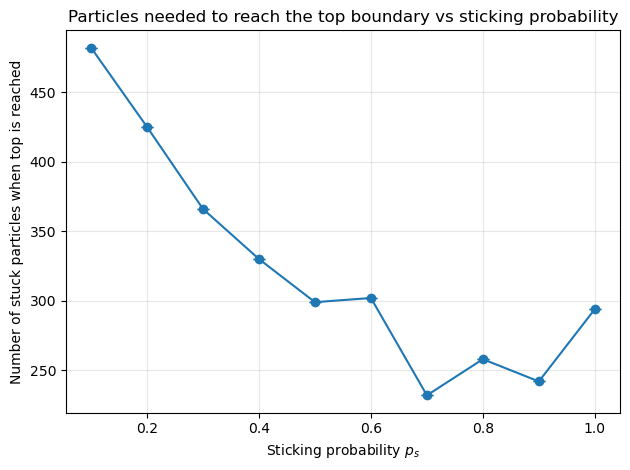

In [ ]:
np.random.seed(0)

grid_size = 50
n_steps = 100000
insert_every = 2
show_every = 100

animate = False
save_snapshots = False

# 10 p_s values
ps_values = np.linspace(0.1, 1.0, 10)

# repetitions per p_s
n_reps = 10

mean_particles_to_top, std_particles_to_top = run_ps_experiment(
    ps_values=ps_values,
    n_reps=n_reps,
    grid_size=grid_size,
    n_steps=n_steps,
    insert_every=insert_every,
    show_every=show_every,
    animate=animate,
    save_snapshots=save_snapshots
)

plot_ps_experiment(ps_values, mean_particles_to_top, std_particles_to_top)

